In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


In [ ]:
from argparse import Namespace
from src.dataset import SDDDataset
from src.utils.plot import get_fig, plt, sns
from src.utils.logger import init_logger

init_logger('src')
args = Namespace(
    hist_step=8, pred_step=1, skip_step=1, roll_step=12, 
    fps=2.5, dot_per_meter=5, seed=2830, 
    debug=False, 
    cache_dataset=False, 
)
datasets = SDDDataset.load_data_batch(args, 'data/SDD/annotations')
# dataset = SDDDataset.load_data(args, 'data/SDD/annotations/deathCircle/video0/annotations.txt')
dataset

[None|sdd_dataset|I|Oct13 09:23:28|0:00:00.004738] Caching dataset-list to data/.cache/SDD-annotations.pkl
Loading SDD datasets:   0%|          | 0/60 [00:00<?, ?it/s, bookstore/video0]

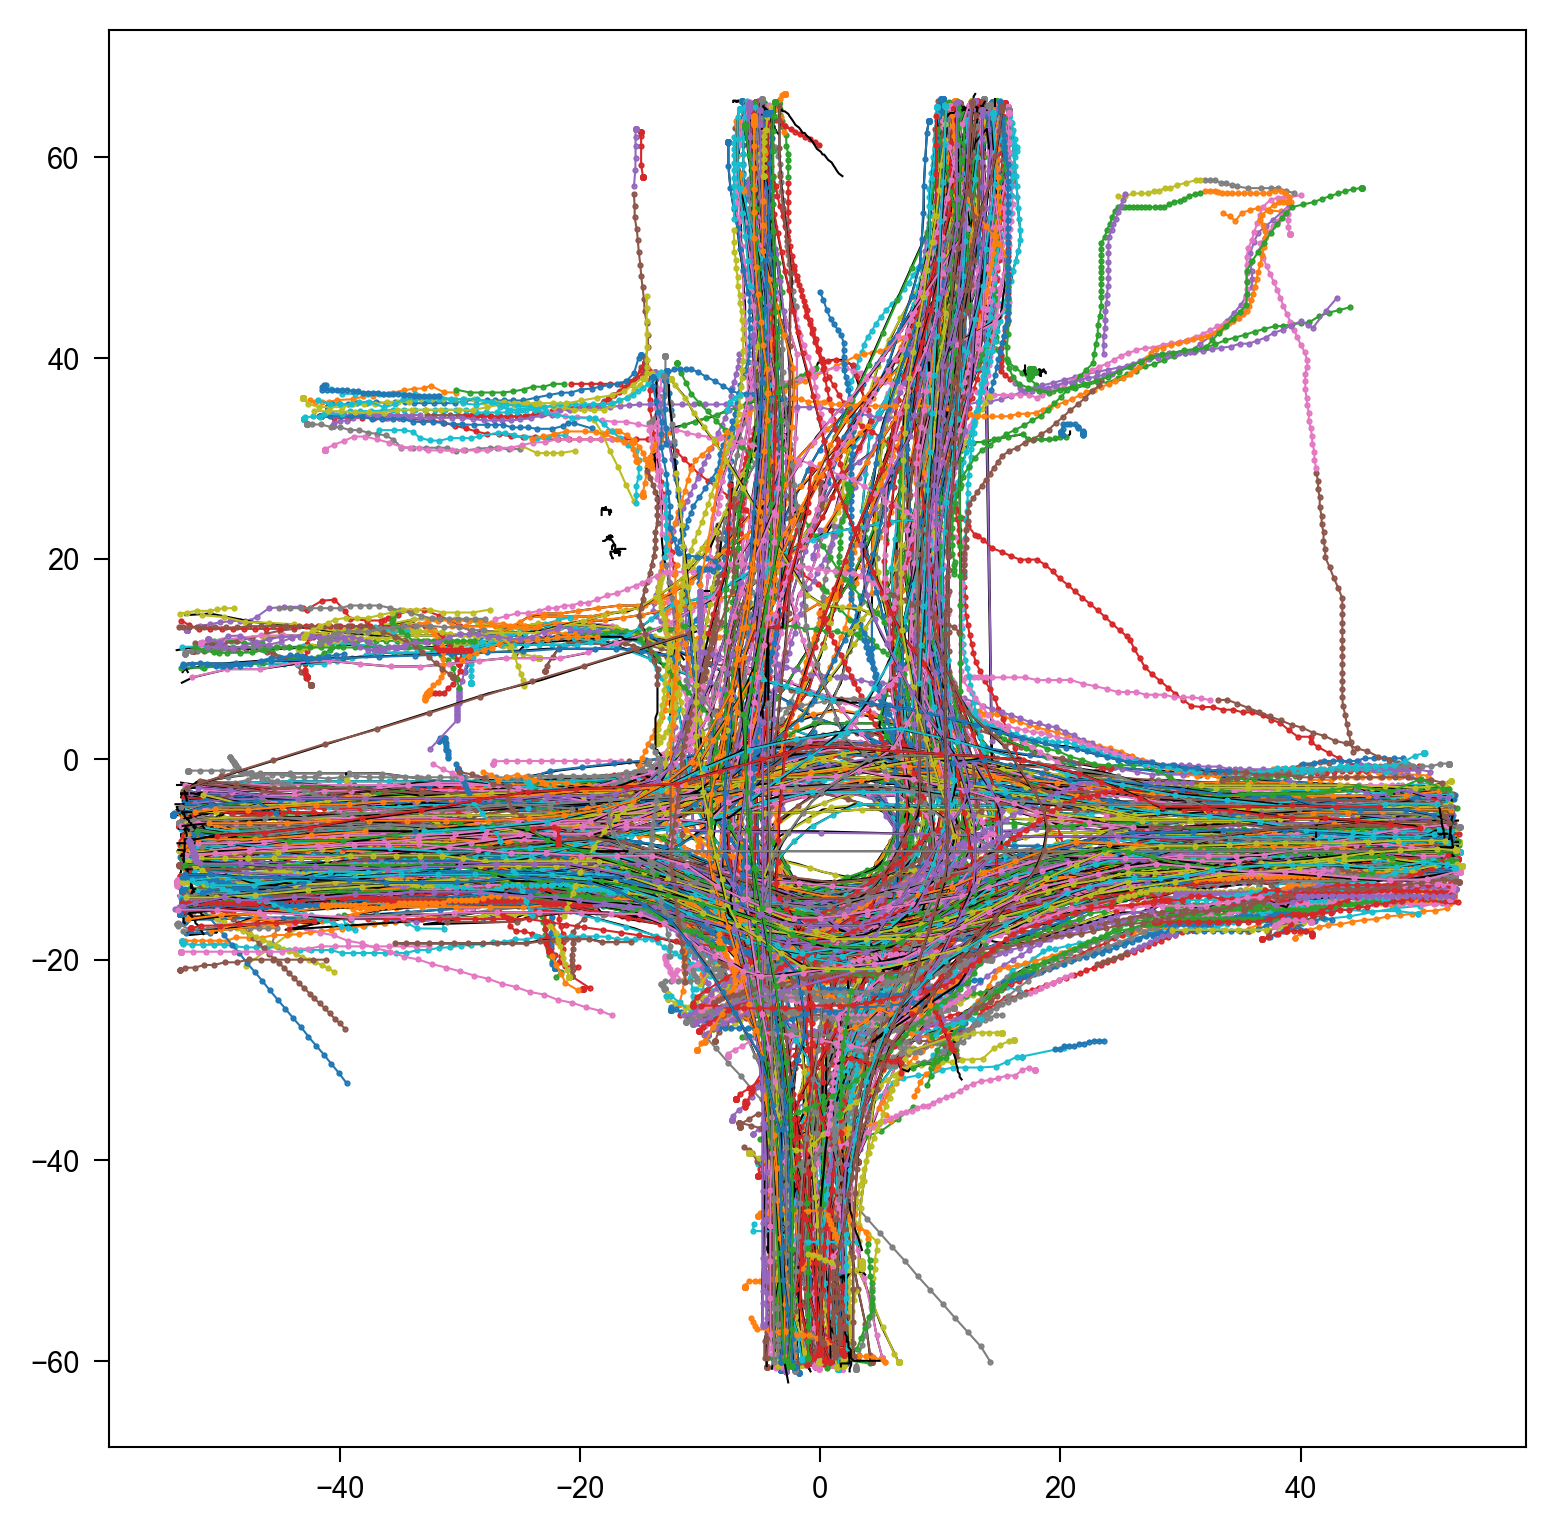

In [9]:
fi, fig, axes = get_fig(1, 1, AW=12, AH=12, dpi=300)

for pid, group in dataset.df_data.groupby('id'):
    if group.iloc[0]['type'] != 'pedestrian':
        axes[0].plot(group['x'], group['y'], '.-', color='black', markersize=0)
    else:
        axes[0].plot(group['x'], group['y'], '.-', markersize=1)

In [163]:
from argparse import Namespace
from src.dataset import SDDDataset
from src.utils.plot import get_fig, plt, sns
from src.utils.logger import init_logger

init_logger('src')
args = Namespace(
    hist_step=8, pred_step=1, skip_step=1, roll_step=12, 
    fps=2.5, dot_per_meter=5, seed=2830, 
    debug=False, 
    cache_dataset=True, 
)
datasets = SDDDataset.load_data_batch(args, 'data/SDD/annotations')

[None|sdd_dataset|I|Oct12 22:56:58|0:00:00.000447] Loading cached dataset-list from data/.cache/SDD-annotations.pkl
Loading SDD datasets: 100%|██████████| 60/60 [00:01<00:00, 35.79it/s, quad/video3]


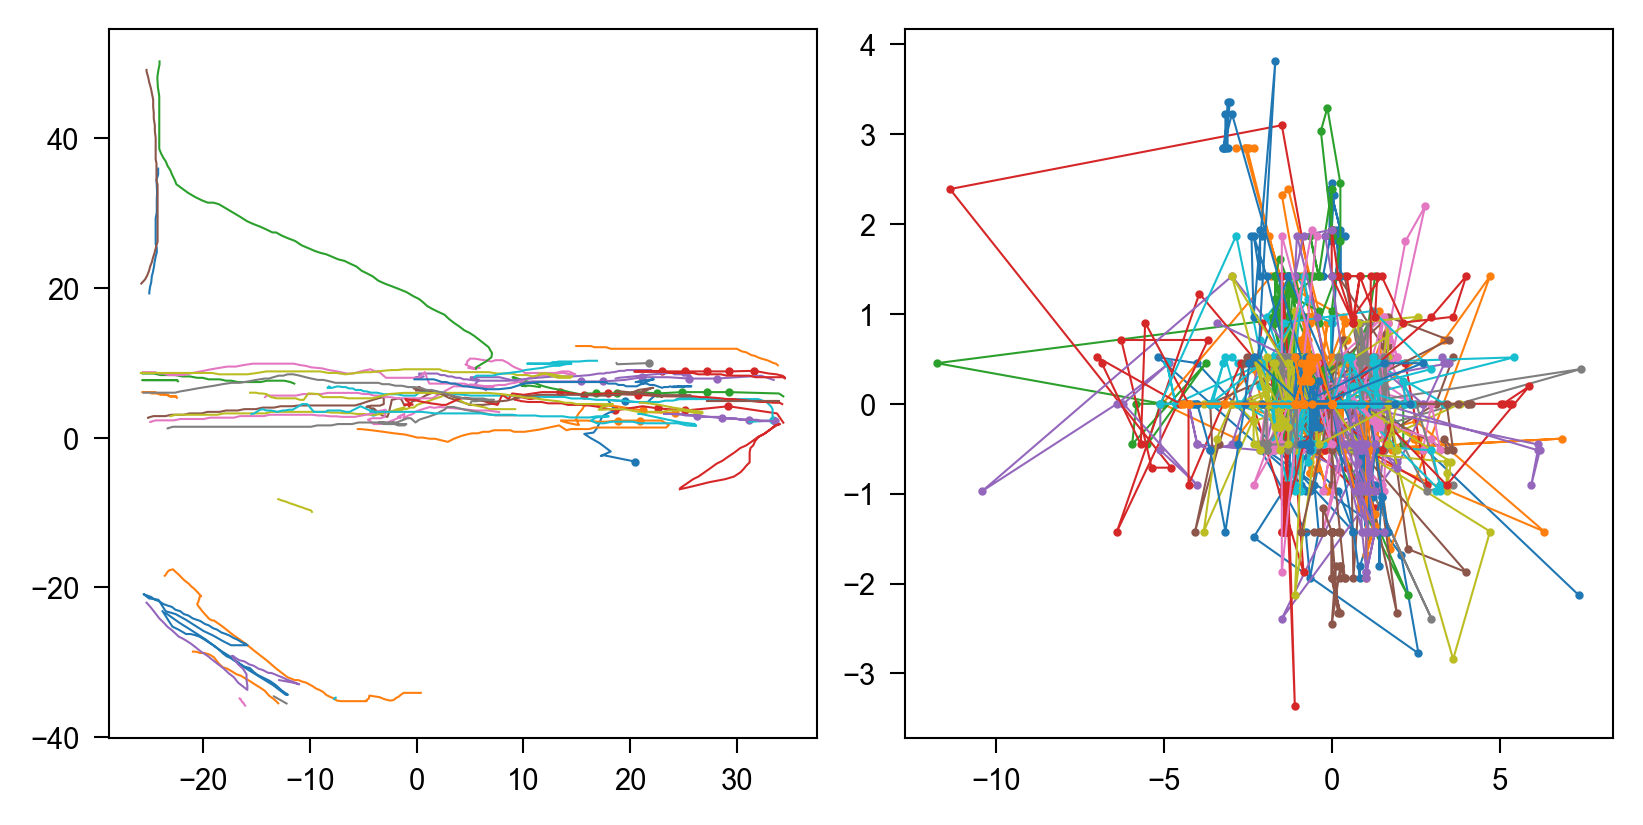

In [44]:
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=300)
df_data = dataset.df_data.sort_values(['id', 'f'])
for pid, group in df_data.groupby('id'):
    if group.iloc[0]['type'] != 'pedestrian': continue
    axes[0].plot(group['x'], group['y'], '-o', markersize=0)
    
    speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5) / group['f'].diff() * args.fps
    tmp = group[speed > 5]
    axes[0].scatter(tmp['x'], tmp['y'], s=1)
    
    vel = group[['x', 'y']].diff() / group[['f']].diff().values * args.fps
    # axes[1].quiver(group['x'], group['y'], vel['x'], vel['y'], angles='xy', scale_units='xy', scale=1, width=0.003, headwidth=3, headlength=5)
    axes[1].plot(vel['x'], vel['y'], '-o', markersize=1)
    # axes[1].set_xlim(-3, 3)
    # axes[1].set_ylim(-3, 3)

In [159]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

def angle_of(dx, dy):
    return np.arctan2(dy, dx)

def circular_diff(a, b):
    d = a - b
    d = (d + np.pi) % (2*np.pi) - np.pi
    return np.abs(d)

def rolling_median_mad(arr, window):
    # returns center-aligned median and MAD arrays (nan at edges)
    n = len(arr)
    med = np.full(n, np.nan)
    mad = np.full(n, np.nan)
    hw = window // 2
    for i in range(n):
        L = max(0, i - hw)
        R = min(n, i + hw + 1)
        w = arr[L:R]
        med[i] = np.median(w)
        mad[i] = np.median(np.abs(w - med[i])) if len(w)>0 else np.nan
    return med, mad

def try_loess(t, y, frac=0.1):
    # optional: use statsmodels if available
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        out = lowess(y, t, frac=frac, return_sorted=False)
        return out
    except Exception:
        return None

def clean_trajectory(traj,
                     median_k=3,
                     do_savgol=True, sg_win=7, sg_poly=2,
                     do_loess=False, loess_frac=0.08,
                     speed_window=11, speed_k=3.0, # for MAD threshold
                     angle_window=11, angle_k=3.0,
                     theta_thresh=np.deg2rad(90.0),
                     split_angle_thresh=np.deg2rad(60.0),
                     split_speed_delta=0.5, 
                     split_time_thresh=1.0):
    """
    traj: (N,3) array of (t,x,y)
    Returns: list of cleaned trajectory segments (each (M,3) array)
    """
    # 1. sort & unique
    traj = np.array(traj)
    order = np.argsort(traj[:,0])
    traj = traj[order]
    # unique by time
    _, idx = np.unique(traj[:,0], return_index=True)
    traj = traj[idx]

    t = traj[:,0]
    x = traj[:,1].copy()
    y = traj[:,2].copy()

    N = len(t)
    if N < 4:
        return []

    # 2. median filter to remove spikes (operate on x,y separately)
    if median_k is not None and median_k >= 3:
        from scipy.signal import medfilt
        # medfilt requires odd kernel and pads; use same length
        k = median_k if median_k%2==1 else median_k+1
        x = medfilt(x, kernel_size=k)
        y = medfilt(y, kernel_size=k)

    # 3. regularize if needed: SG requires at least window length points and evenly sampled
    if do_savgol:
        if sg_win >= N:
            sg_win = N-1 if (N-1)%2==1 else N-2
            if sg_win < 3:
                do_savgol = False
        if do_savgol:
            try:
                x = savgol_filter(x, window_length=sg_win, polyorder=sg_poly, mode='interp')
                y = savgol_filter(y, window_length=sg_win, polyorder=sg_poly, mode='interp')
            except Exception:
                do_savgol = False

    # 4. LOESS as alternative (overrides SG if requested and available)
    if do_loess:
        xs = try_loess(t, x, frac=loess_frac)
        ys = try_loess(t, y, frac=loess_frac)
        if xs is not None and ys is not None:
            x, y = xs, ys

    # 5. compute velocities and directions
    dt = np.diff(t)
    vxs = np.diff(x) / dt
    vys = np.diff(y) / dt
    speeds = np.sqrt(vxs**2 + vys**2)  # length N-1
    # pad to length N for per-point measures (associate speed[i] as speed from i->i+1)
    speeds_p = np.concatenate(([speeds[0]], speeds))
    angles = angle_of(np.concatenate(([vxs[0]], vxs)), np.concatenate(([vys[0]], vys)))

    # 6. local median & MAD on speed and on angle differences
    med_speed, mad_speed = rolling_median_mad(speeds_p, speed_window)
    # robust threshold
    mad_eps = 1.4826 * mad_speed
    # indicator of speed anomaly (use k * MAD)
    speed_diff = np.abs(speeds_p - med_speed)
    is_speed_anom = (speed_diff > speed_k * mad_eps) | np.isnan(speed_diff)

    # angle change anomaly: look at difference between local median angles
    # compute local median angle
    med_angle, mad_angle = rolling_median_mad(angles, angle_window)
    # angle difference to median
    angle_diff = circular_diff(angles, med_angle)
    # indicator of speed anomaly (use k * MAD)
    mad_eps = 1.4826 * mad_angle
    # 将转角过大的点标记为异常
    delta_theta = circular_diff(angles[:-2], angles[2:])  # length N-1
    delta_theta = np.concatenate(([0.0], delta_theta, [0.0]))  # pad to length N
    is_angle_anom = (angle_diff > angle_k * mad_eps) | np.isnan(angle_diff) | (delta_theta > theta_thresh)

    # combine anomalies
    is_point_anom = is_speed_anom | is_angle_anom

    # 7. group consecutive anomalies into segments
    segments = []
    i = 0
    while i < N:
        if not is_point_anom[i]:
            i += 1
            continue
        # start a candidate anomaly region
        j = i
        while j+1 < N and is_point_anom[j+1]:
            j += 1
        # region [i..j]
        L = max(0, i-3)  # context window
        R = min(N-1, j+3)
        # compute med speed/angle left vs right
        left_idx = range(L, i)
        right_idx = range(j+1, R+1)
        if len(left_idx) == 0 or len(right_idx) == 0:
            # edge case near start/end -> prefer split or trim
            # if small region, remove by interpolation
            do_split = False if (j-i)<=1 else True
        else:
            v_left = np.median(speeds_p[list(left_idx)])
            v_right = np.median(speeds_p[list(right_idx)])
            theta_left = np.median(angles[list(left_idx)])
            theta_right = np.median(angles[list(right_idx)])
            # decide
            do_split = (abs(v_left - v_right) > split_speed_delta) or (circular_diff(theta_left, theta_right) > split_angle_thresh) or ((t[j] - t[i]) > split_time_thresh)

        if do_split:
            # cut trajectory: flush segment before i (if any) and start new segment after j
            # we add the clean chunk from previous pointer up to i-1 as a segment
            segments.append(('split', i, j))
        else:
            segments.append(('interp', i, j))
        i = j+1

    # 8. apply interpolation / splitting to produce final segments
    # Strategy: accumulate indices to include in each output segment
    cut_points = set()
    to_remove_intervals = []
    for typ, a, b in segments:
        if typ == 'split':
            # indicate a split between a-1 and a, and between b and b+1
            cut_points.add(a)   # split before index a
            cut_points.add(b+1) # split before b+1 (i.e., after b)
        else:
            # interpolation: mark indices a..b for removal and interpolation
            to_remove_intervals.append((a,b))

    # build segments by cutting at cut_points (sorted)
    cuts = sorted(list(cut_points))
    # always include start 0 and end N
    boundaries = [0] + cuts + [N]
    final_segments = []
    for sidx in range(len(boundaries)-1):
        st = boundaries[sidx]
        ed = boundaries[sidx+1]
        # segment indices [st, ed)
        if ed - st < 2:
            continue
        seg_t = t[st:ed].copy()
        seg_x = x[st:ed].copy()
        seg_y = y[st:ed].copy()
        final_segments.append(np.stack((seg_t, seg_x, seg_y), axis=1))

    # now apply interpolation removals within each final segment
    def apply_interps(segment):
        seg_t = segment[:,0]
        seg_x = segment[:,1]
        seg_y = segment[:,2]
        # find intervals fully contained in this segment
        base_start = seg_t[0]
        base_end = seg_t[-1]
        keep_mask = np.ones(len(seg_t), dtype=bool)
        for a,b in to_remove_intervals:
            # check if [a..b] indices map into this segment
            # map by time: if any times in segment correspond to indices a..b in original
            # original times are t
            idxs = np.where((t >= t[a]) & (t <= t[b]))[0]
            if len(idxs)==0:
                continue
            # mark these indices for removal
            rel = np.where((seg_t >= t[a]) & (seg_t <= t[b]))[0]
            keep_mask[rel] = False
        if np.all(keep_mask):
            return segment
        # else, build new t/x/y with interpolation across removed points
        new_t = seg_t[keep_mask]
        new_x = seg_x[keep_mask]
        new_y = seg_y[keep_mask]
        # But we must ensure we can interpolate across gaps: check if gap endpoints exist
        # Use linear interpolation on time
        f_x = interp1d(new_t, new_x, kind='linear', bounds_error=False, fill_value="extrapolate")
        f_y = interp1d(new_t, new_y, kind='linear', bounds_error=False, fill_value="extrapolate")
        full_x = f_x(seg_t)
        full_y = f_y(seg_t)
        return np.stack((seg_t, full_x, full_y), axis=1)

    cleaned = [apply_interps(seg) for seg in final_segments]
    # filter tiny segments (<2 points)
    cleaned = [c for c in cleaned if len(c) >= 3]
    cleaned = [c for c in cleaned if np.sum(np.sqrt(np.sum(np.square(np.diff(c[:, 1:], axis=0)), axis=1))) > 3.0]  # remove near-constant segments
    return cleaned


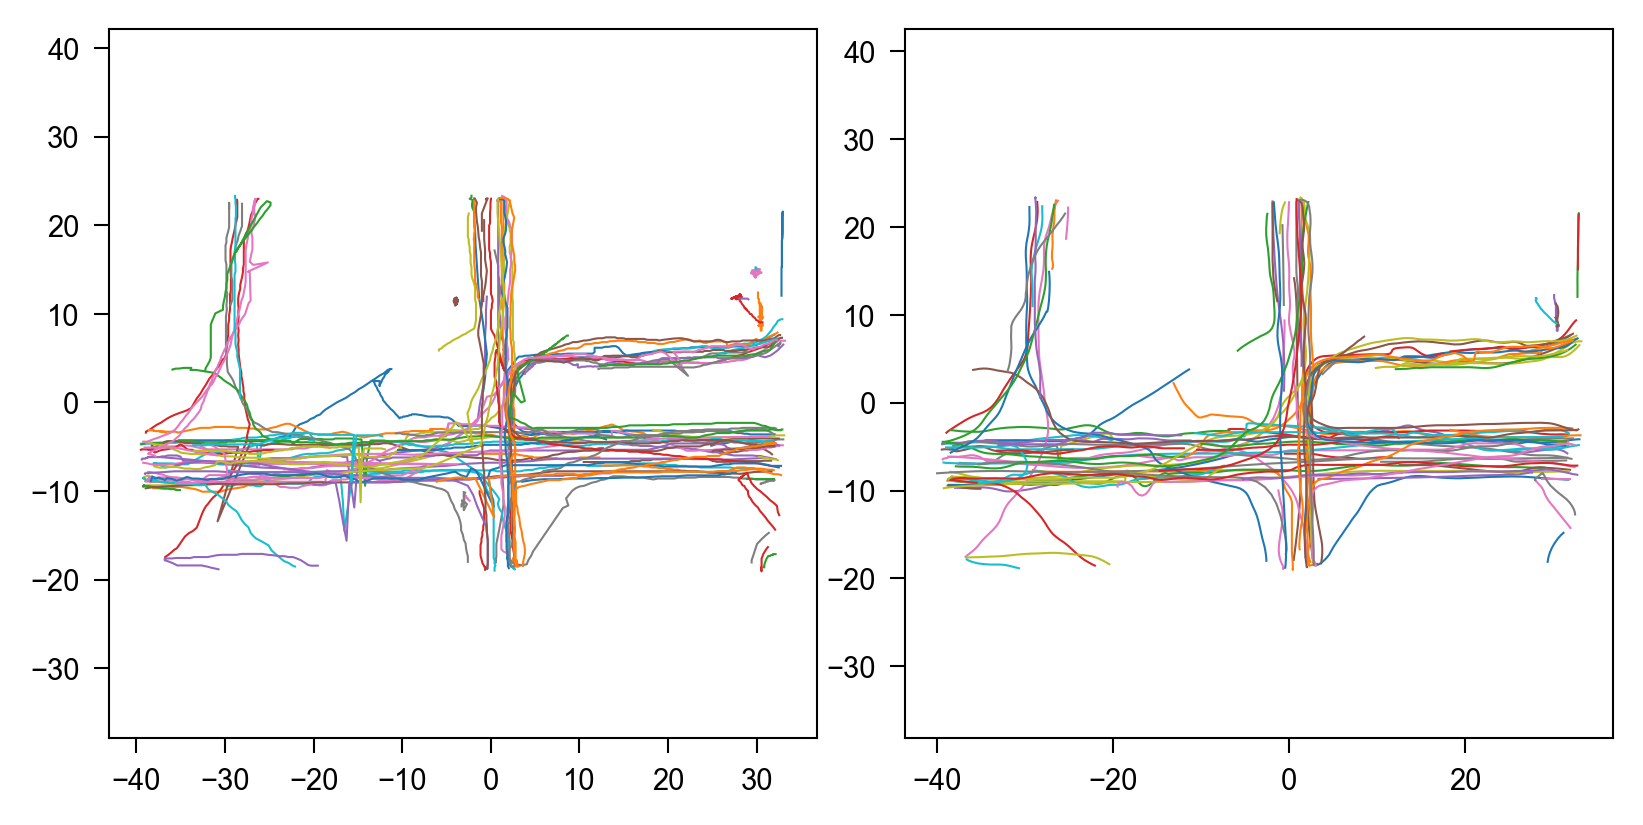

In [171]:
fi, fig, axes = get_fig(1, 2, AW=6, AH=6, dpi=300)
axes[0].axis('equal')
axes[1].axis('equal')

cnt = 0
import random
dataset = random.choice(datasets)
df_data = dataset.df_data.sort_values(['id', 'f'])
for pid, group in df_data.groupby('id'):
    if group.iloc[0]['type'] != 'pedestrian': continue
    # if (cnt := cnt + 1) == 50: break
    
    axes[0].plot(group['x'], group['y'], '-o', markersize=0)

    traj = group[['f', 'x', 'y']].values
    traj[:, 0] /= args.fps  # convert to seconds
    cleaned_segs = clean_trajectory(traj,
                                    median_k=5,
                                    do_savgol=True, sg_win=9, sg_poly=2,
                                    do_loess=False, loess_frac=0.08,
                                    speed_window=11, speed_k=5.0,
                                    angle_window=11, angle_k=5.0,
                                    theta_thresh=np.deg2rad(90.0),
                                    split_angle_thresh=np.deg2rad(120.0),
                                    split_speed_delta=0.5, 
                                    split_time_thresh=1.0)
    for seg in cleaned_segs:
        axes[1].plot(seg[:,1], seg[:,2], '-o', markersize=0)
    